In [16]:
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

data_dir = os.path.join(os.getcwd(), 'data')
subj_files = sorted(glob.glob(os.path.join(data_dir, '*.csv')))

all_subj_df = pd.DataFrame()
excl_summary_list = []

for subj in subj_files:
    subj_id = subj.split('_')[4].split('.')[0]
    print(f'Processing subject {subj_id} ...')

    # load dataframe
    df = pd.read_csv(subj)
    n_total = len(df)
    num_blank = len(df[df['correct'] == -1]) # blank trials
    n_total_completed = n_total - num_blank

    num_incorrect = len(df[df['correct'] == 0]) # incorrect == 0 response
    df = df[df['correct'] == 1]

    num_rt_outliers = len(df[(df['RT'] <= 200) | (df['RT'] >= 1500)])
    df = df[(df['RT'] > 200) & (df['RT'] < 1500)]

    # exclude trials where pupil size larger or smaller than 3 SDs from mean
    # (should i exclude before or after incorrect and slow/fast responses?)
    pupil_mean = df['pupil_b_raw'].mean()
    pupil_std = df['pupil_b_raw'].std()
    num_pupil_outliers = len(df[(df['pupil_b_raw'] < (pupil_mean - 3 * pupil_std)) | 
                                (df['pupil_b_raw'] > (pupil_mean + 3 * pupil_std))])
    df = df[(df['pupil_b_raw'] >= (pupil_mean - 3 * pupil_std)) & (df['pupil_b_raw'] <= (pupil_mean + 3 * pupil_std))]

    num_excluded_total = num_incorrect + num_rt_outliers + num_pupil_outliers

    n_final = len(df)
    excl_summary_list.append({
        'subject_id': subj_id,
        'n_total_trials': n_total,
        'n_total_trials_completed': n_total_completed,
        'n_blank_trials': num_blank,
        'n_incorrect_excluded': num_incorrect,
        'n_rt_outliers_excluded': num_rt_outliers,
        'n_pupil_outliers_excluded': num_pupil_outliers,
        'n_excluded_total': num_excluded_total,
        'n_final_trials': n_final,
        'perc_completed': round(100 * (n_total - num_blank) / n_total, 2),
        'perc_blank': round(100 * num_blank / n_total, 2),
        'perc_incorrect': round(100 * num_incorrect / n_total_completed, 2),
        'perc_rt_outliers': round(100 * num_rt_outliers / n_total_completed, 2),
        'perc_pupil_outliers': round(100 * num_pupil_outliers / n_total_completed, 2),
        'perc_total_excluded': round(100 * num_excluded_total / n_total_completed, 2),
        'perc_remaining': round(100 * n_final / n_total, 2)
    })

    # z-score per run
    df['pupil_zscore'] = (df['pupil_b_raw'] - df.groupby('run_id')['pupil_b_raw'].transform('mean')) / df.groupby('run_id')['pupil_b_raw'].transform('std')
    df['RT_log'] = np.log(df['RT'])
    df['pupil_zscore_squared'] = df['pupil_zscore'] ** 2 

    df['bin'] = df.groupby('run_id')['pupil_zscore'].transform(lambda x: pd.qcut(x, q=5, labels=[1, 2, 3, 4, 5]))
    # df['bin_RT_mean'] = df.groupby('bin', observed=True)['RT'].transform('mean')
    # df['bin_RT_log_mean'] = df.groupby('bin', observed=True)['RT_log'].transform('mean')
    # df['bin_pupil_mean'] = df.groupby('bin')['pupil_b_raw'].transform('mean') # does not make sense to keep this since we are binning based on z-score
    # df['bin_pupil_z_mean'] = df.groupby('bin', observed=True)['pupil_zscore'].transform('mean')

    # get beta coefficients for linear and quadratic models
    y = df['RT_log']
    X_lin = df[['pupil_zscore']]
    X_lin = sm.add_constant(X_lin)

    X_poly = df[['pupil_zscore', 'pupil_zscore_squared']]
    X_poly = sm.add_constant(X_poly)

    lin_model = sm.OLS(y, X_lin).fit()
    df['RT_pred_lin'] = lin_model.predict(X_lin)
    df['beta0_lin'] = lin_model.params['const']
    df['beta1_lin'] = lin_model.params['pupil_zscore']
    df['r2_lin'] = lin_model.rsquared   

    quad_model = sm.OLS(y, X_poly).fit()
    df['RT_pred_quad'] = quad_model.predict(X_poly)
    df['beta0_quad'] = quad_model.params['const']
    df['beta1_quad'] = quad_model.params['pupil_zscore']
    df['beta2_quad'] = quad_model.params['pupil_zscore_squared']
    df['r2_quad'] = quad_model.rsquared

    all_subj_df = pd.concat([all_subj_df, df], ignore_index=True)

# save combined dataframe
all_subj_df.drop(columns=["Unnamed: 0"], inplace=True)
all_subj_df.to_csv(os.path.join(os.getcwd(), 'all_subjects_processed.csv'), index=False)

# summary statistics
# blank trials not included in esxclusion counts
excl_summary_df = pd.DataFrame(excl_summary_list)
excl_summary_df.to_csv(os.path.join(os.getcwd(),'exclusion_summary.csv'), index=False)

totals = excl_summary_df[['n_total_trials', 'n_total_trials_completed', 'n_blank_trials', 'n_incorrect_excluded','n_rt_outliers_excluded','n_pupil_outliers_excluded','n_excluded_total', 'n_final_trials']].sum()
means  = excl_summary_df[['n_blank_trials', 'n_incorrect_excluded','n_rt_outliers_excluded','n_pupil_outliers_excluded','n_excluded_total']].mean()
mean_perc = excl_summary_df[['perc_blank', 'perc_incorrect','perc_rt_outliers','perc_pupil_outliers','perc_total_excluded', 'perc_remaining', 'perc_completed']].mean()

print("\n=== Total Number of Excluded Trials (All Participants) ===")
print(totals)

print("\n=== Average Number of Excluded Trials Per Participant ===")
print(means.round(2))

print("\n=== Average Percentage of Trials Per Exclusion Type ===")
print(mean_perc.round(2))

Processing subject sub-001 ...
Processing subject sub-002 ...
Processing subject sub-003 ...
Processing subject sub-004 ...
Processing subject sub-005 ...
Processing subject sub-006 ...
Processing subject sub-007 ...
Processing subject sub-008 ...
Processing subject sub-009 ...
Processing subject sub-010 ...
Processing subject sub-011 ...
Processing subject sub-012 ...
Processing subject sub-013 ...
Processing subject sub-014 ...
Processing subject sub-015 ...
Processing subject sub-016 ...
Processing subject sub-017 ...
Processing subject sub-018 ...

=== Total Number of Excluded Trials (All Participants) ===
n_total_trials               15516
n_total_trials_completed     13066
n_blank_trials                2450
n_incorrect_excluded           571
n_rt_outliers_excluded          17
n_pupil_outliers_excluded       58
n_excluded_total               646
n_final_trials               12420
dtype: int64

=== Average Number of Excluded Trials Per Participant ===
n_blank_trials               1

In [17]:
# excl_summary_df
all_subj_df

,subject_id,session_id,run_id,trial_id,time_phase_0,time_phase_1,time_phase_2,blank_trial,signal_present,signal_orientation,...,bin,RT_pred_lin,beta0_lin,beta1_lin,r2_lin,RT_pred_quad,beta0_quad,beta1_quad,beta2_quad,r2_quad
0,sub-001,ses-01,run-0,3,16.302,16.801,17.301,0,1,45.0,...,5,6.234030,6.239075,-0.002672,0.000441,6.242125,6.235080,-0.003868,0.004024,0.002257
1,sub-001,ses-01,run-0,4,20.301,20.801,21.301,0,1,45.0,...,5,6.235160,6.239075,-0.002672,0.000441,6.238052,6.235080,-0.003868,0.004024,0.002257
2,sub-001,ses-01,run-0,5,24.302,24.801,25.301,0,1,45.0,...,5,6.233408,6.239075,-0.002672,0.000441,6.244978,6.235080,-0.003868,0.004024,0.002257
3,sub-001,ses-01,run-0,6,28.301,28.801,29.301,0,1,-45.0,...,5,6.234143,6.239075,-0.002672,0.000441,6.241652,6.235080,-0.003868,0.004024,0.002257
4,sub-001,ses-01,run-0,8,36.301,36.800,37.300,0,1,45.0,...,5,6.237301,6.239075,-0.002672,0.000441,6.234286,6.235080,-0.003868,0.004024,0.002257
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12415,sub-018,ses-01,run-4,191,847.150,847.649,848.149,0,1,45.0,...,2,6.439580,6.427580,-0.018737,0.007044,6.436402,6.413294,-0.026855,0.014403,0.013397
12416,sub-018,ses-01,run-4,192,851.149,851.649,852.149,0,0,-1.0,...,1,6.447885,6.427580,-0.018737,0.007044,6.459310,6.413294,-0.026855,0.014403,0.013397
12417,sub-018,ses-01,run-4,193,855.150,855.649,856.149,0,0,-1.0,...,1,6.444101,6.427580,-0.018737,0.007044,6.448170,6.413294,-0.026855,0.014403,0.013397
12418,sub-018,ses-01,run-4,196,867.150,867.649,868.153,0,1,45.0,...,1,6.452589,6.427580,-0.018737,0.007044,6.474798,6.413294,-0.026855,0.014403,0.013397


In [18]:
# summary statistics
mean_rt = all_subj_df['RT'].mean()
std_rt = all_subj_df['RT'].std()
mean_pupil = all_subj_df['pupil_b_raw'].mean()
std_pupil = all_subj_df['pupil_b_raw'].std()
mean_pupil_psc = all_subj_df['pupil_b_psc'].mean()
std_pupil_psc = all_subj_df['pupil_b_psc'].std()

print("\n=== Summary Statistics Across All Participants ===")
print(f"Mean RT: {mean_rt:.2f} ms, SD RT: {std_rt:.2f} ms")
print(f"Mean Pupil (raw): {mean_pupil:.2f}, SD Pupil (raw): {std_pupil:.2f}")
print(f"Mean Pupil (psc): {mean_pupil_psc:.2f}, SD Pupil (psc): {std_pupil_psc:.2f}")


=== Summary Statistics Across All Participants ===
Mean RT: 595.62 ms, SD RT: 124.50 ms
Mean Pupil (raw): 2559.89, SD Pupil (raw): 892.74
Mean Pupil (psc): -1.26, SD Pupil (psc): 20.69


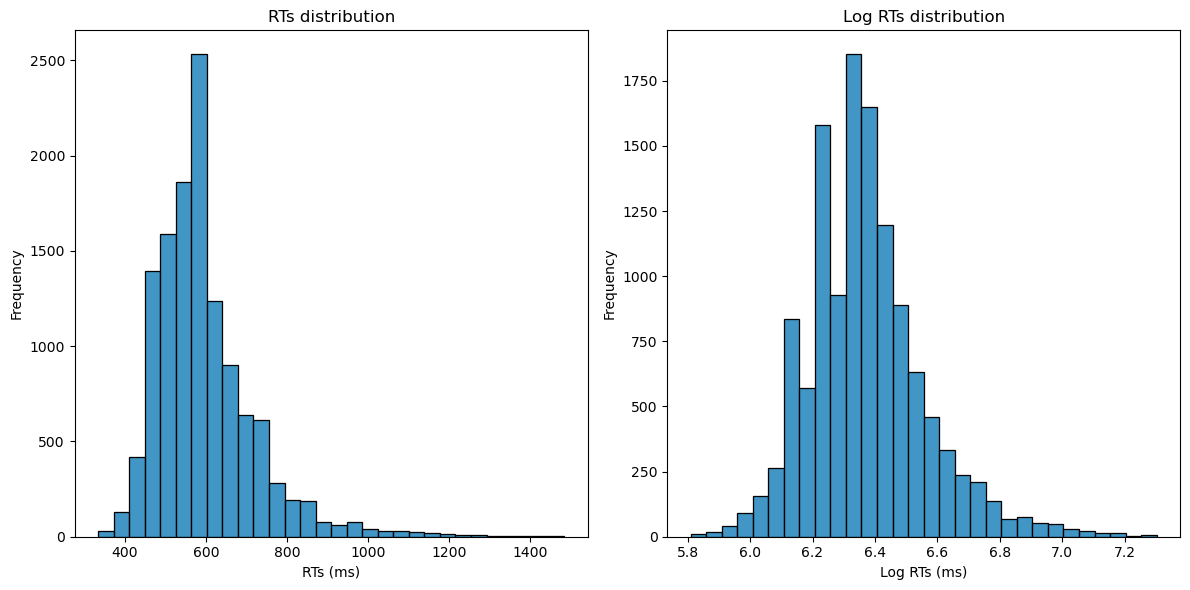

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(data=all_subj_df, x='RT', bins=30, ax=ax[0])
ax[0].set_title('RTs distribution')
ax[0].set_xlabel('RTs (ms)')
ax[0].set_ylabel('Frequency')

sns.histplot(data=all_subj_df, x='RT_log', bins=30, ax=ax[1])
ax[1].set_title('Log RTs distribution')
ax[1].set_xlabel('Log RTs (ms)')
ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [20]:
# fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# for subj in all_subj_df['subject_id'].unique():
#     sns.histplot(all_subj_df[all_subj_df['subject_id'] == subj]['RT'], label=f"subj-{subj}", alpha=0.5, ax=ax[0])
#     sns.histplot(all_subj_df[all_subj_df['subject_id'] == subj]['RT_log'], label=f"subj-{subj}", alpha=0.5, ax=ax[1])

# ax[0].set_title('RT distribution by subject')
# ax[0].set_xlabel('RTs (ms)')
# ax[0].set_ylabel('Frequency')

# ax[1].set_title('Log RT distribution by subject')
# ax[1].set_xlabel('Log RTs (ms)')
# ax[1].set_ylabel('')
# ax[1].legend()

# plt.tight_layout()
# plt.show()

In [21]:
# fig, ax = plt.subplots(2, 2, figsize=(8, 8))

# sns.scatterplot(data=all_subj_df, x='pupil_b_raw', y='RT', ax=ax[0, 0])
# ax[0, 0].set_title('RT vs Pupil Size (raw)')
# ax[0, 0].set_xlabel('Pupil Size (a.u.)')
# ax[0, 0].set_ylabel('RT (ms)')

# sns.scatterplot(data=all_subj_df, x='pupil_zscore', y='RT', ax=ax[0, 1])
# ax[0, 1].set_title('RT vs Pupil Size (z-scored)')
# ax[0, 1].set_xlabel('Z-scored Pupil Size')
# ax[0, 1].set_ylabel('RT (ms)')

# sns.scatterplot(data=all_subj_df, x='pupil_b_raw', y='RT_log', ax=ax[1, 0])
# ax[1, 0].set_title('Log RT vs Pupil Size (raw)')
# ax[1, 0].set_xlabel('Pupil Size (a.u.)')
# ax[1, 0].set_ylabel('Log RT')

# # Bottom-right: RT vs z-scored pupil size
# sns.scatterplot(data=all_subj_df, x='pupil_zscore', y='RT_log', ax=ax[1, 1])
# ax[1, 1].set_title('Log RT vs Pupil Size (z-scored)')
# ax[1, 1].set_xlabel('Z-scored Pupil Size')
# ax[1, 1].set_ylabel('Log RT')

# plt.tight_layout()
# plt.show()

In [22]:
# bin_means_lin = all_subj_df.groupby('bin', observed=True)[['RT_pred_lin', 'pupil_zscore']].mean()
# bin_means_quad = all_subj_df.groupby('bin', observed=True)[['RT_pred_quad', 'pupil_zscore']].mean()
# RT_pred_std_lin = np.std(all_subj_df['RT_pred_lin'])
# RT_pred_std_quad = np.std(all_subj_df['RT_pred_quad'])

In [23]:
bin_means = all_subj_df.groupby('bin', observed=True).agg(
    pupil_z_mean = ('pupil_zscore', 'mean'),
    pupil_z_std = ('pupil_zscore', 'std'),
    RT_log_mean = ('RT_log', 'mean'),
    RT_log_std = ('RT_log', 'std'),
    RT_log_sem = ('RT_log', lambda x: x.std() / np.sqrt(len(x)))
).reset_index()

RT_log_std = np.std(all_subj_df['RT_log']) 
pupil_zscore_std = np.std(all_subj_df['pupil_zscore'])

bin_means

,bin,pupil_z_mean,pupil_z_std,RT_log_mean,RT_log_std,RT_log_sem
0,1,-1.316833,0.381336,6.374662,0.191512,0.003813
1,2,-0.579711,0.197116,6.370945,0.193360,0.003895
2,3,-0.045312,0.192424,6.365841,0.186118,0.003746
3,4,0.518867,0.221505,6.374068,0.184906,0.003724
4,5,1.432340,0.511617,6.367523,0.191883,0.003837


In [24]:
betas_lin = all_subj_df.groupby('subject_id')[['beta0_lin', 'beta1_lin']].first()
betas_lin

,beta0_lin,beta1_lin
subject_id,,
sub-001,6.239075,-0.002672
sub-002,6.421272,-0.014869
sub-003,6.514295,0.012545
sub-004,6.386189,0.003551
sub-005,6.178682,-0.003989
sub-006,6.506664,-0.022953
sub-007,6.331978,-0.001704
sub-008,6.323095,0.015034
sub-009,6.325892,0.003699


In [25]:
betas_quad = all_subj_df.groupby('subject_id')[['beta0_quad', 'beta1_quad', 'beta2_quad']].first()
betas_quad

,beta0_quad,beta1_quad,beta2_quad
subject_id,,,
sub-001,6.235080,-0.003868,0.004024
sub-002,6.420603,-0.015313,0.000674
sub-003,6.524253,0.016559,-0.010028
sub-004,6.382068,0.001238,0.004151
sub-005,6.184671,-0.002442,-0.006033
sub-006,6.483822,-0.029715,0.023026
sub-007,6.332355,-0.001638,-0.000380
sub-008,6.327203,0.015042,-0.004137
sub-009,6.323579,0.003045,0.002331


One sample t-test for β1 and β2

In [26]:
from scipy.stats import ttest_1samp

# t-test for beta 1 
tstat1, pval1 = ttest_1samp(betas_lin['beta1_lin'], popmean=0)
print(f'One sample t-test for β1:')
print(f'T-statistic: {tstat1}, P-value: {pval1}')

# t-test for beta 2
tstat2, pval2 = ttest_1samp(betas_quad['beta2_quad'], popmean=0)
print(f'\nOne sample t-test for β2:')
print(f'T-statistic: {tstat2}, P-value: {pval2}')

One sample t-test for β1:
T-statistic: -0.4063492137879352, P-value: 0.689555595220831

One sample t-test for β2:
T-statistic: 1.8882823462383465, P-value: 0.07617584659648853


Mixed Effects Analysis (check R Studio for analysis)

In [27]:
# import statsmodels.formula.api as smf
# from statsmodels.tools.sm_exceptions import ConvergenceWarning

# linear_mixed = smf.mixedlm("RT_log ~ pupil_zscore", 
#                          all_subj_df, 
#                          groups=all_subj_df["subject_id"],
#                          re_formula="~pupil_zscore")
# linear_fit = linear_mixed.fit(method='lbfgs')

# quad_mixed = smf.mixedlm("RT_log ~ pupil_zscore + pupil_zscore_squared", 
#                     data=all_subj_df,
#                     groups=all_subj_df["subject_id"],
#                     re_formula="~pupil_zscore + pupil_zscore_squared")
# quad_fit = quad_mixed.fit(method='lbfgs')

# print(linear_fit.summary())
# print(quad_fit.summary())

Visualizations

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Use the entire dataset for fits
x = all_subj_df['pupil_zscore'].values.reshape(-1, 1)
y = all_subj_df['RT_log'].values

# Generate smooth x range for plotting
x_vals = np.linspace(all_subj_df['pupil_zscore'].min(), all_subj_df['pupil_zscore'].max(), 200).reshape(-1,1)

# Linear fit
lin_reg = LinearRegression().fit(x, y)
y_linear_fit = lin_reg.predict(x_vals)

# Quadratic fit
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(x)
quad_reg = LinearRegression().fit(X_poly, y)
X_poly_pred = poly.transform(x_vals)
y_quad_fit = quad_reg.predict(X_poly_pred)

def bootstrap_regression(x, y, x_pred, degree=1, n_boot=20000):
    preds = np.zeros((n_boot, len(x_pred)))
    for i in range(n_boot):
        idx = np.random.choice(len(x), len(x), replace=True)
        x_sample, y_sample = x[idx], y[idx]
        if degree == 1:
            model = LinearRegression().fit(x_sample, y_sample)
            preds[i] = model.predict(x_pred)
        elif degree == 2:
            poly = PolynomialFeatures(degree=2, include_bias=False)
            Xs = poly.fit_transform(x_sample)
            model = LinearRegression().fit(Xs, y_sample)
            Xp = poly.transform(x_pred)
            preds[i] = model.predict(Xp)
    return preds

# bootstrap 95% CI for both models (approx. 20 seconds)
boot_lin = bootstrap_regression(x, y, x_vals, degree=1)
boot_quad = bootstrap_regression(x, y, x_vals, degree=2)

y_lin_mean = boot_lin.mean(axis=0)
y_lin_lower = np.percentile(boot_lin, 2.5, axis=0)
y_lin_upper = np.percentile(boot_lin, 97.5, axis=0)

y_quad_mean = boot_quad.mean(axis=0)
y_quad_lower = np.percentile(boot_quad, 2.5, axis=0)
y_quad_upper = np.percentile(boot_quad, 97.5, axis=0)

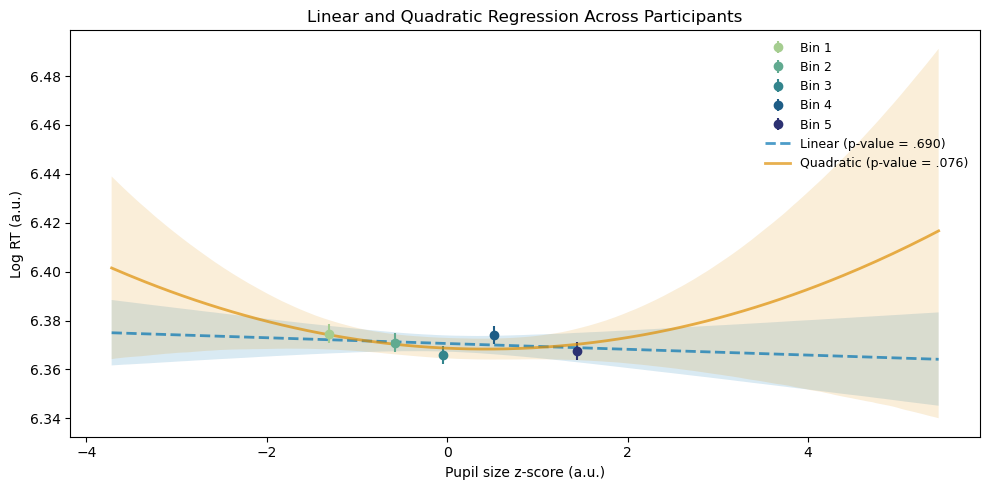

In [36]:
# plot
sns.set_palette('colorblind') # colorblind-friendly color palette
cmap = sns.color_palette('crest', as_cmap=True)
plt.figure(figsize=(10,5))

# raw data
# sns.scatterplot(x='pupil_zscore', y='RT_log', data=all_subj_df, alpha=0.1, color='gray', label='Raw data')

# binned means
# sns.scatterplot(data=bin_means, x='pupil_z_mean', y='RT_log_mean', hue='bin', palette='crest', s=100)
for i in range(5):
    c = cmap((i)/4)
    plt.errorbar(bin_means['pupil_z_mean'][i], bin_means['RT_log_mean'][i], yerr=bin_means['RT_log_sem'][i], 
                 fmt='o', markersize=6, c=c, label=f'Bin {i+1}')

# linear and quadratic fits
plt.plot(x_vals, y_linear_fit, linestyle='--', linewidth=2, alpha=0.7, label='Linear (p-value = .690)')
plt.fill_between(x_vals.flatten(), y_lin_lower, y_lin_upper, alpha=0.15)
plt.plot(x_vals, y_quad_fit, linewidth=2, alpha=0.7, label='Quadratic (p-value = .076)')
plt.fill_between(x_vals.flatten(), y_quad_lower, y_quad_upper, alpha=0.15)

plt.title('Linear and Quadratic Regression Across Participants')
plt.xlabel('Pupil size z-score (a.u.)')
plt.ylabel('Log RT (a.u.)')

handles, labels = plt.gca().get_legend_handles_labels()
order = [2, 3, 4, 5, 6, 0, 1]
plt.legend([handles[i] for i in order], [labels[i] for i in order],
    loc='upper right', frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(os.getcwd(), 'results_across_subjects.svg'), format='svg', dpi=300)
plt.show()

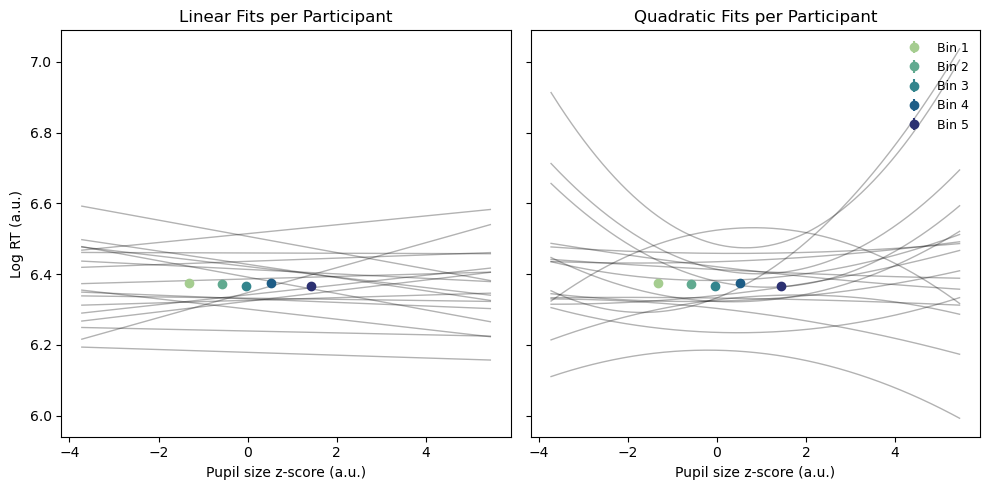

In [37]:
# plot
sns.set_palette('colorblind') # colorblind-friendly color palette
cmap = sns.color_palette('crest', as_cmap=True)
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

for i in range(5):
    c = cmap((i)/4)
    ax[0].errorbar(bin_means['pupil_z_mean'][i], bin_means['RT_log_mean'][i], yerr=bin_means['RT_log_sem'][i], 
                 fmt='o', markersize=6, c=c, label=f'Bin {i+1}')

for _, row in betas_lin.iterrows():
    y_lin = row['beta0_lin'] + row['beta1_lin'] * x_vals
    ax[0].plot(x_vals, y_lin, color='black', alpha=0.3, linewidth=1)

ax[0].set_title('Linear Fits per Participant', fontsize=12)
ax[0].set_xlabel('Pupil size z-score (a.u.)')
ax[0].set_ylabel('Log RT (a.u.)')
ax[0].grid(False)

for i in range(5):
    c = cmap((i)/4)
    ax[1].errorbar(bin_means['pupil_z_mean'][i], bin_means['RT_log_mean'][i], yerr=bin_means['RT_log_sem'][i], 
                 fmt='o', markersize=6, c=c, label=f'Bin {i+1}')

for _, row in betas_quad.iterrows():
    y_quad = (
        row['beta0_quad'] +
        row['beta1_quad'] * x_vals +
        row['beta2_quad'] * (x_vals ** 2)
    )
    ax[1].plot(x_vals, y_quad, color='black', alpha=0.3, linewidth=1)


ax[1].set_title('Quadratic Fits per Participant', fontsize=12)
ax[1].set_xlabel('Pupil size z-score (a.u.)')
ax[1].grid(False)
ax[1].legend(loc='upper right', frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(os.getcwd(), 'results_per_subjects.svg'), format='svg', dpi=300)
plt.show()